In [1]:
# ============================================
# Brain Tumor MRI - Data Preprocessing
# SE4050 Deep Learning Assignment
# ============================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully.")
print("Random seed:", SEED)

Libraries imported successfully.
Random seed: 42


In [2]:
# ============================================
# Dataset Paths
# ============================================

from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset directories
TRAIN_DIR = PROJECT_ROOT / "archive" / "Training"
TEST_DIR = PROJECT_ROOT / "archive" / "Testing"

print("Project root :", PROJECT_ROOT)
print("Training path:", TRAIN_DIR)
print("Testing path :", TEST_DIR)

# Verify paths exist
print("\nPath verification:")
print("Training exists:", TRAIN_DIR.exists())
print("Testing exists :", TEST_DIR.exists())

Project root : /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit
Training path: /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/archive/Training
Testing path : /Users/mirshad/Desktop/brain-tumor/brain-tumor-vit/archive/Testing

Path verification:
Training exists: True
Testing exists : True


In [3]:
# ============================================
# Dataset Class and Image Count Verification
# ============================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def count_images(folder):
    return sum(
        1 for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

# Get class names
classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print("Classes:", classes)
print()

# Count training images
print("Training dataset:")
training_counts = {}

for class_name in classes:
    class_path = TRAIN_DIR / class_name
    count = count_images(class_path)
    training_counts[class_name] = count
    print(f"{class_name:12s}: {count}")

print(f"\nTotal training images: {sum(training_counts.values())}")

# Count testing images
print("\nTesting dataset:")
testing_counts = {}

for class_name in classes:
    class_path = TEST_DIR / class_name
    count = count_images(class_path)
    testing_counts[class_name] = count
    print(f"{class_name:12s}: {count}")

print(f"\nTotal testing images: {sum(testing_counts.values())}")

# Overall total
total_images = sum(training_counts.values()) + sum(testing_counts.values())
print(f"\nTotal dataset images: {total_images}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training dataset:
glioma      : 1400
meningioma  : 1400
notumor     : 1400
pituitary   : 1400

Total training images: 5600

Testing dataset:
glioma      : 400
meningioma  : 400
notumor     : 400
pituitary   : 400

Total testing images: 1600

Total dataset images: 7200


In [4]:
# ============================================
# Image Quality and Format Check
# ============================================

from collections import Counter

def inspect_images(folder):
    dimension_counts = Counter()
    format_counts = Counter()
    corrupted_files = []

    image_paths = [
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    for path in image_paths:
        try:
            with Image.open(path) as img:
                # Check that the image can be fully read
                img.verify()

            # Re-open because verify() invalidates the image object
            with Image.open(path) as img:
                dimension_counts[img.size] += 1
                format_counts[img.format] += 1

        except Exception:
            corrupted_files.append(str(path))

    return dimension_counts, format_counts, corrupted_files


# Inspect Training dataset
train_dimensions, train_formats, train_corrupted = inspect_images(TRAIN_DIR)

# Inspect Testing dataset
test_dimensions, test_formats, test_corrupted = inspect_images(TEST_DIR)


# --------------------------------------------
# Display results
# --------------------------------------------

print("TRAINING DATASET")
print("----------------")
print("Image dimensions:")
for dimension, count in train_dimensions.most_common():
    print(f"{dimension}: {count}")

print("\nImage formats:")
for image_format, count in train_formats.most_common():
    print(f"{image_format}: {count}")

print(f"\nCorrupted training images: {len(train_corrupted)}")


print("\n\nTESTING DATASET")
print("----------------")
print("Image dimensions:")
for dimension, count in test_dimensions.most_common():
    print(f"{dimension}: {count}")

print("\nImage formats:")
for image_format, count in test_formats.most_common():
    print(f"{image_format}: {count}")

print(f"\nCorrupted testing images: {len(test_corrupted)}")


# --------------------------------------------
# Overall summary
# --------------------------------------------

print("\n\nQUALITY SUMMARY")
print("----------------")
print("Total corrupted images:",
      len(train_corrupted) + len(test_corrupted))

TRAINING DATASET
----------------
Image dimensions:
(512, 512): 4012
(225, 225): 253
(630, 630): 69
(201, 251): 40
(236, 236): 39
(442, 442): 38
(150, 198): 33
(232, 217): 32
(228, 221): 32
(428, 417): 31
(200, 252): 29
(206, 244): 26
(201, 250): 26
(173, 201): 26
(192, 192): 25
(256, 256): 22
(218, 231): 22
(227, 222): 20
(227, 262): 19
(214, 236): 19
(468, 444): 19
(215, 234): 19
(236, 213): 17
(504, 540): 17
(359, 449): 16
(208, 242): 16
(230, 282): 15
(550, 664): 15
(400, 442): 15
(393, 400): 14
(442, 454): 13
(441, 442): 13
(339, 340): 12
(680, 680): 12
(196, 257): 11
(350, 350): 11
(207, 243): 11
(276, 326): 11
(235, 214): 10
(420, 280): 10
(356, 474): 8
(300, 168): 8
(212, 238): 8
(194, 259): 8
(380, 530): 7
(275, 183): 6
(350, 393): 6
(177, 197): 6
(236, 357): 5
(1024, 1024): 5
(235, 227): 5
(201, 210): 4
(275, 301): 4
(208, 248): 4
(416, 512): 4
(236, 269): 4
(220, 275): 4
(1338, 1304): 3
(892, 826): 3
(202, 202): 3
(1335, 1302): 3
(624, 607): 3
(900, 741): 3
(785, 848): 3
(64

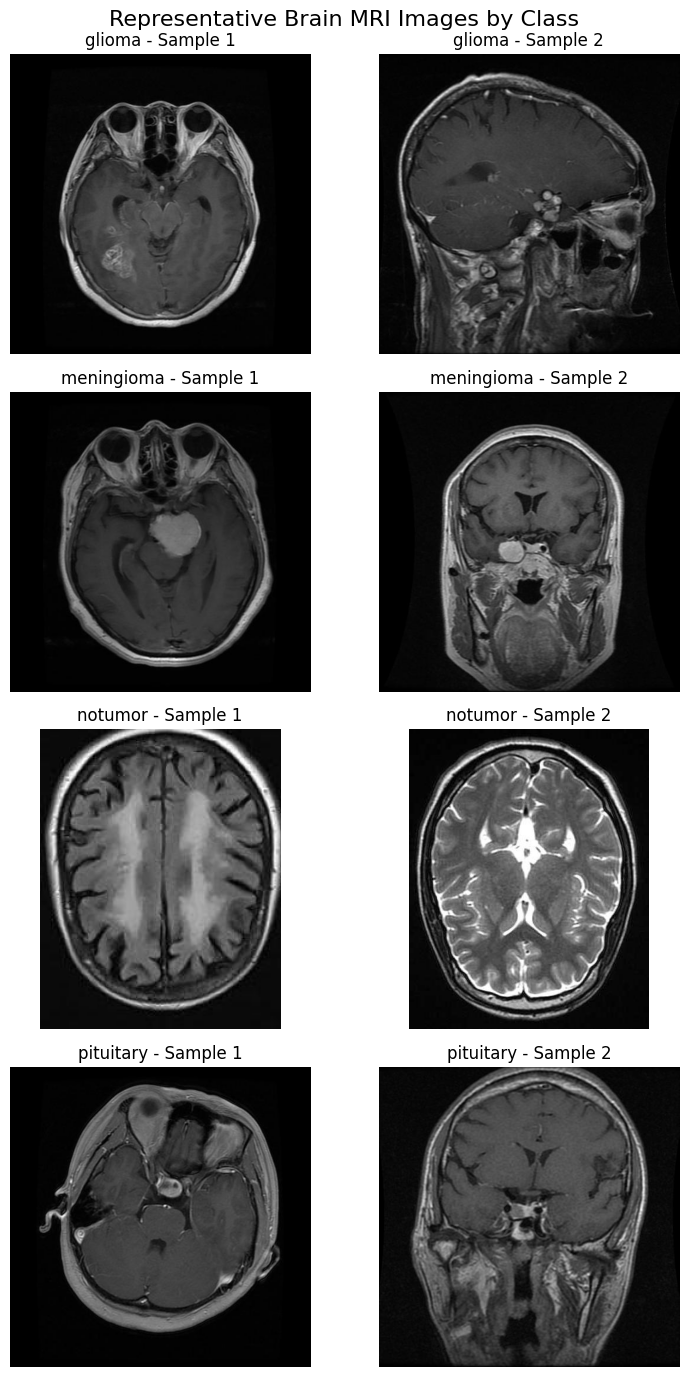

In [5]:
# ============================================
# Visualize Two MRI Samples per Class
# ============================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(8, 14)
)

for row, class_name in enumerate(classes):

    class_path = TRAIN_DIR / class_name

    image_files = [
        path for path in class_path.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]

    # Select two images
    selected_images = image_files[:2]

    for col, image_path in enumerate(selected_images):

        with Image.open(image_path) as img:
            img = img.convert("RGB")

            axes[row, col].imshow(img)
            axes[row, col].set_title(
                f"{class_name} - Sample {col + 1}"
            )
            axes[row, col].axis("off")

plt.suptitle(
    "Representative Brain MRI Images by Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

Training class distribution:


,Class,Count
0,glioma,1400
1,meningioma,1400
2,notumor,1400
3,pituitary,1400



Testing class distribution:


,Class,Count
0,glioma,400
1,meningioma,400
2,notumor,400
3,pituitary,400


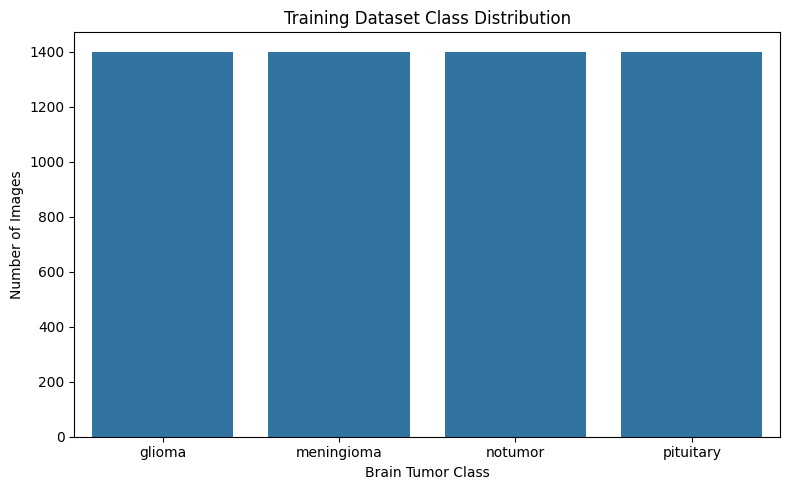

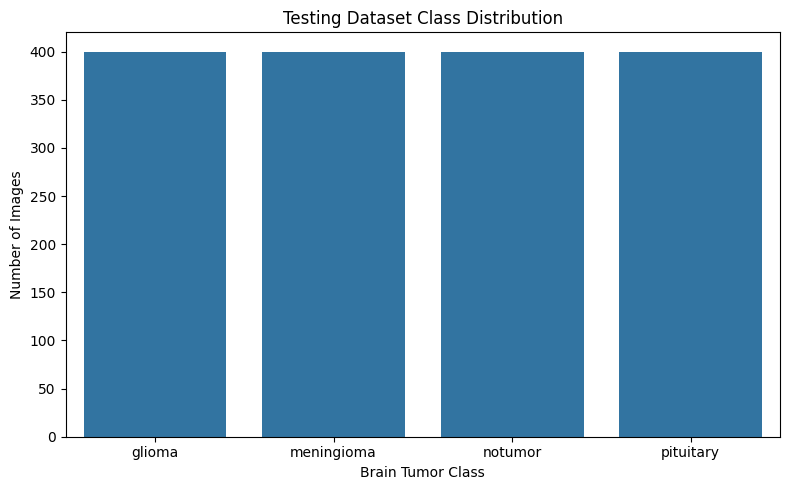

In [6]:
# ============================================
# Class Distribution Analysis
# ============================================

# Create DataFrames for plotting
train_df = pd.DataFrame({
    "Class": list(training_counts.keys()),
    "Count": list(training_counts.values())
})

test_df = pd.DataFrame({
    "Class": list(testing_counts.keys()),
    "Count": list(testing_counts.values())
})

# Display counts
print("Training class distribution:")
display(train_df)

print("\nTesting class distribution:")
display(test_df)

# Plot training distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    data=train_df,
    x="Class",
    y="Count"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

# Plot testing distribution
plt.figure(figsize=(8, 5))

sns.barplot(
    data=test_df,
    x="Class",
    y="Count"
)

plt.title("Testing Dataset Class Distribution")
plt.xlabel("Brain Tumor Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# Stratified Train / Validation Split
# ============================================

from sklearn.model_selection import train_test_split

# Collect all training image paths and labels
image_paths = []
labels = []

for class_name in classes:
    class_path = TRAIN_DIR / class_name

    for image_path in class_path.iterdir():
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            image_paths.append(str(image_path))
            labels.append(class_name)

# Create dataframe
train_data = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("Total training samples:", len(train_data))
print("\nOriginal class distribution:")
print(train_data["label"].value_counts())

# Stratified 80/20 split
train_split, val_split = train_test_split(
    train_data,
    test_size=0.20,
    random_state=SEED,
    stratify=train_data["label"]
)

# Reset indices
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)

# Display results
print("\nSplit results:")
print("Training samples  :", len(train_split))
print("Validation samples:", len(val_split))

print("\nTraining distribution:")
print(train_split["label"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_split["label"].value_counts().sort_index())

Total training samples: 5600

Original class distribution:
label
glioma        1400
meningioma    1400
notumor       1400
pituitary     1400
Name: count, dtype: int64

Split results:
Training samples  : 4480
Validation samples: 1120

Training distribution:
label
glioma        1120
meningioma    1120
notumor       1120
pituitary     1120
Name: count, dtype: int64

Validation distribution:
label
glioma        280
meningioma    280
notumor       280
pituitary     280
Name: count, dtype: int64


In [8]:
# ============================================
# ViT-B/16 Image Preprocessing
# ============================================

from torchvision import transforms

# ViT-B/16 standard input size
IMAGE_SIZE = 224

# ImageNet normalization used for the pretrained ViT
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# --------------------------------------------
# Training transformations
# --------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(degrees=7),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# --------------------------------------------
# Validation transformations
# --------------------------------------------
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# --------------------------------------------
# Test transformations
# --------------------------------------------
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Image size:", IMAGE_SIZE)
print("Training transform:", train_transform)
print("Validation transform:", val_transform)
print("Testing transform:", test_transform)

Image size: 224
Training transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-7.0, 7.0], interpolation=nearest, expand=False, fill=0)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Validation transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Testing transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [9]:
# ============================================
# PyTorch Dataset and DataLoader
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader


# Class-to-index mapping
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print("Class mapping:")
print(class_to_idx)


class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "image_path"]
        label_name = self.dataframe.loc[index, "label"]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform:
            image = self.transform(image)

        label = class_to_idx[label_name]

        return image, label


# --------------------------------------------
# Create testing dataframe
# --------------------------------------------

test_paths = []
test_labels = []

for class_name in classes:
    class_path = TEST_DIR / class_name

    for image_path in class_path.iterdir():
        if (
            image_path.is_file()
            and image_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            test_paths.append(str(image_path))
            test_labels.append(class_name)

test_df = pd.DataFrame({
    "image_path": test_paths,
    "label": test_labels
})

print("\nDataset sizes:")
print("Train      :", len(train_split))
print("Validation :", len(val_split))
print("Test       :", len(test_df))


# --------------------------------------------
# Create Dataset objects
# --------------------------------------------

train_dataset = BrainMRIDataset(
    train_split,
    transform=train_transform
)

val_dataset = BrainMRIDataset(
    val_split,
    transform=val_transform
)

test_dataset = BrainMRIDataset(
    test_df,
    transform=test_transform
)


# --------------------------------------------
# Create DataLoaders
# --------------------------------------------

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print("\nDataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Dataset sizes:
Train      : 4480
Validation : 1120
Test       : 1600

DataLoaders created successfully.
Batch size: 4


In [10]:
# ============================================
# Verify One Batch
# ============================================

images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Labels            :", labels.tolist())

print("\nExpected image shape:")
print("[batch_size, channels, height, width]")
print("[4, 3, 224, 224]")

Image batch shape : torch.Size([4, 3, 224, 224])
Label batch shape : torch.Size([4])
Labels            : [0, 0, 3, 1]

Expected image shape:
[batch_size, channels, height, width]
[4, 3, 224, 224]


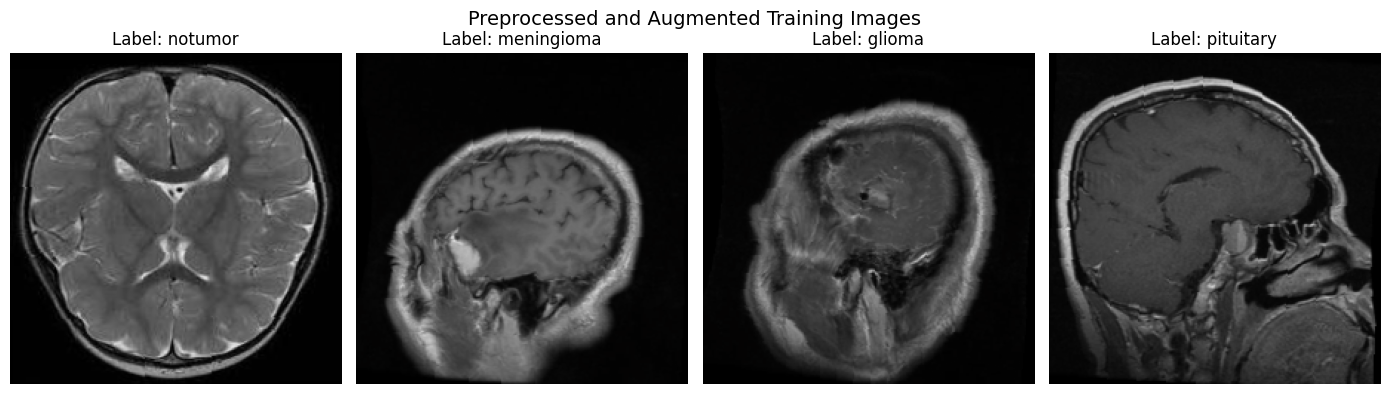

In [12]:
# ============================================
# Visualize Preprocessed / Augmented Images
# ============================================

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

images, labels = next(iter(train_loader))

num_images = len(images)

fig, axes = plt.subplots(
    1,
    num_images,
    figsize=(14, 4)
)

if num_images == 1:
    axes = [axes]

for i in range(num_images):

    # Undo normalization for visualization
    image = images[i].cpu() * std + mean
    image = torch.clamp(image, 0, 1)

    # [C, H, W] → [H, W, C]
    image = image.permute(1, 2, 0).numpy()

    axes[i].imshow(image)
    axes[i].set_title(
        f"Label: {idx_to_class[labels[i].item()]}"
    )
    axes[i].axis("off")

plt.suptitle(
    "Preprocessed and Augmented Training Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# M1 GPU / MPS Verification
# ============================================

print("PyTorch version:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device:", device)
else:
    device = torch.device("cpu")
    print("MPS unavailable. Using CPU.")

PyTorch version: 2.8.0
MPS built: True
MPS available: True
Using device: mps
